# **Datu Zientzia Ariketak**
Koaderno honetan NumPy, Pandas eta Seaborn erabiliz ariketak egingo ditugu.

Lehenik, exekutatu hurrengo gelaxka datuak (Kaggle estiloan) prestatzeko.


## Setup (Datuen sorkuntza)
Exekutatu beheko gelaxka `data` karpeta eta beharrezko fitxategiak sortzeko.

In [1]:
# @title
import os
import pandas as pd
import numpy as np

# Sortu data karpeta
os.makedirs('data', exist_ok=True)

# Sortu datu faltsuak (mock data)
np.random.seed(42)
data = {
    'makina_id': ['M1', 'M2', 'M3', 'M1', 'M2', 'M3', 'M1', 'M2', 'M3', 'M1'] * 10,
    'tenperatura': np.random.normal(60, 10, 100),
    'bibrazioa': np.random.normal(5, 2, 100),
    'errorea': np.random.choice([0, 1], 100, p=[0.9, 0.1])
}
df_mock = pd.DataFrame(data)

# Sartu anomaliak eta NaNak
df_mock.loc[5, 'tenperatura'] = np.nan
df_mock.loc[12, 'bibrazioa'] = np.nan
df_mock.loc[45, 'tenperatura'] = 999  # Outlier
df_mock.loc[78, 'bibrazioa'] = -50  # Outlier

df_mock.to_csv('data/cnc_mock.csv', index=False)
print('✅ data/cnc_mock.csv fitxategia sortu da anomalia eta NaNekin!')


✅ data/cnc_mock.csv fitxategia sortu da anomalia eta NaNekin!


# 1. NumPy


## APUNTEETAKO ARIKETAK



**Ariketa 1.2**, 6. orrialdea: Klase bateko 6 ikasleren 4 azterketako notak
dituzu.
Eginkizuna:
1. Sortu 6×4 array bat ausazko notekin (`np.random.randint(0, 11, (6, 4))`), hazia 42-
an finkatuta.
2. Inprimatu bere `shape`, `ndim` eta `size`.
3. `reshape`-ekin bihurtu 4×6 array batean, eta gero `flatten`ekin bektore bakar batean.
4. Azaldu: zergatik funtzionatzen du `reshape(4, 6)`ek baina ez `reshape(5, 5)`ek?

In [ ]:
# @title
import numpy as np

np.random.seed(42)
# 1. 6 ikasle × 4 azterketa ausazko notak
notak = np.random.randint(0, 11, (6, 4))
print("Notak (6x4):")
print(notak)

# 2. Ezaugarriak
print(f"shape: {notak.shape}")   # (6, 4)
print(f"ndim:  {notak.ndim}")    # 2
print(f"size:  {notak.size}")    # 24

# 3. Forma-aldaketak
notak_4x6 = notak.reshape(4, 6)
print(f"\n4x6 forma-aldatua:\n{notak_4x6}")
print(f"shape berria: {notak_4x6.shape}")

bektorea = notak.flatten()
print(f"\nFlatten (1D): {bektorea}")
print(f"shape: {bektorea.shape}")   # (24,)

# 4. reshape(5, 5) saiakera
try:
    notak.reshape(5, 5)
except ValueError as e:
    print(f"\nErrorea: {e}")


Notak (6x4):
[[ 6  3 10  7]
 [ 4  6  9  2]
 [ 6 10 10  7]
 [ 4  3  7  7]
 [ 2  5  4  1]
 [ 7  5  1  4]]
shape: (6, 4)
ndim:  2
size:  24

4x6 forma-aldatua:
[[ 6  3 10  7  4  6]
 [ 9  2  6 10 10  7]
 [ 4  3  7  7  2  5]
 [ 4  1  7  5  1  4]]
shape berria: (4, 6)

Flatten (1D): [ 6  3 10  7  4  6  9  2  6 10 10  7  4  3  7  7  2  5  4  1  7  5  1  4]
shape: (24,)

Errorea: cannot reshape array of size 24 into shape (5,5)


## ARIKETA OSAGARRIAK

**Ariketa 1.1:** Inportatu `numpy` eta sortu `arr1` izeneko 1D array bat 1etik 10era bitarteko zenbakiekin.


In [ ]:
import numpy as np
# Zure kodea hemen:
arr1 = np.arange(1, 11)
print(arr1)

# Balioztapena:
assert type(arr1) == np.ndarray, "arr1 numpy array bat izan behar da!"
assert len(arr1) == 10, "10 elementu izan behar ditu!"
assert arr1[0] == 1 and arr1[-1] == 10, "1etik 10era bitartekoa izan behar da!"
print('✅ Zuzena!')


[ 1  2  3  4  5  6  7  8  9 10]
✅ Zuzena!


**Ariketa 1.2:** Sortu `arr2` izeneko 3x3 matrize bat, zeroz betea (`np.zeros`).


In [ ]:
# Zure kodea hemen:
arr2 = np.zeros((3, 3))
print(arr2)

# Balioztapena:
assert arr2.shape == (3, 3), "3x3 tamaina izan behar du!"
assert np.all(arr2 == 0), "Zeroz betea egon behar da!"
print('✅ Zuzena!')


[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
✅ Zuzena!


**Ariketa 1.3:** Sortu `arr3` izeneko 10 balio aleatorioko array bat (`np.random.rand`) eta gorde bere balio maximoa `max_val` aldagaian.


In [ ]:
# Zure kodea hemen:
arr3 = np.random.rand(10)
print(arr3)
max_val = np.max(arr3)
print(max_val)

# Balioztapena:
assert len(arr3) == 10, "10 elementu izan behar ditu!"
assert max_val == np.max(arr3), "max_val balio maximoa izan behar da!"
print('✅ Zuzena!')


[0.61748151 0.61165316 0.00706631 0.02306243 0.52477466 0.39986097
 0.04666566 0.97375552 0.23277134 0.09060643]
0.9737555188414592
✅ Zuzena!


**Ariketa 1.4:** Sortu `arr4` non `arr1`-eko elementu guztiak 2rekin biderkatuta dauden.


In [ ]:
# Zure kodea hemen:
arr4 = arr1 * 2

# Balioztapena:
assert np.all(arr4 == arr1 * 2), "arr1-eko elementuak bider 2 izan behar dira!"
print('✅ Zuzena!')


✅ Zuzena!


**Ariketa 1.5:** Sortu `arr5` izeneko array bat 0tik 11ra bitarteko balioekin (12 elementu). Gero, bihurtu 3x4 matrize batean eta gorde `mat1` aldagaian (`reshape`).


In [ ]:
# Zure kodea hemen:
arr5 = np.arange(12)
print(arr5)
mat1 = arr5.reshape(3, 4)
print(mat1)

# Balioztapena:
assert len(arr5) == 12, "12 elementu izan behar ditu!"
assert mat1.shape == (3, 4), "3x4 matrizea izan behar da!"
print('✅ Zuzena!')


[ 0  1  2  3  4  5  6  7  8  9 10 11]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
✅ Zuzena!


# 2. Boolean Indexazioa


## APUNTEETAKO ARIKETAK

**Ariketa 1.4**, 11. orrialdea

Egoera: Saltoki bateko 10 produkturen stock-a: `[12, 0, 45, 3, 0, 78, 5, 0, 23, 1]`.

Eginkizuna:
1.  Zenbat produktu agortuta dauden zenbatu.
2.  Stock baxuko produktuak (`0 < stock < 5`) lortu.
3.  Stock baxuko guztiei (`stock < 5`) balioa 10ra aldatu.


In [ ]:
# @title
import numpy as np

stock = np.array([12, 0, 45, 3, 0, 78, 5, 0, 23, 1])

# 1. Agortuak (stock == 0)
agortuak = stock == 0
print(f"Agortuen maska: {agortuak}")
print(f"Agortu kopurua: {agortuak.sum()}")   # 3
# Alternatiba: np.count_nonzero(stock == 0)

# 2. Stock baxua: 0 < stock < 5 (parentesiak DERRIGORREZKOAK)
baxua = (stock > 0) & (stock < 5)
print(f"\nStock baxuko produktuak: {stock[baxua]}")   # [3 1]
print(f"Zenbaki indizeak: {np.where(baxua)[0]}")      # [3 9]

# 3. Stock < 5 dutenak (agortuak barne) 10era aldatu
stock_birhornitua = stock.copy()        # Jatorrizkoa ez aldatu (ohitura ona)
stock_birhornitua[stock_birhornitua < 5] = 10
print(f"\nBirhornitu ondoren: {stock_birhornitua}")
# [12 10 45 10 10 78 10 10 23 10]


Agortuen maska: [False  True False False  True False False  True False False]
Agortu kopurua: 3

Stock baxuko produktuak: [3 1]
Zenbaki indizeak: [3 9]

Birhornitu ondoren: [12 10 45 10 10 78  5 10 23 10]


**Ariketa 1.5** , 13. orrialdea

Egoera: 3 denda × 4 hiruhileko salmenta-matrizea: [[120, 135, 150, 165], [90, 95, 110, 100], [200, 210, 195, 220]].

Eginkizuna:
1.  Denda bakoitzaren urteko salmenta osoa.
2.  Hiruhileko bakoitzeko batezbesteko salmenta dendetan zehar.
3.  Salmenta-aldakortasun handieneko denda (std).


In [ ]:
# @title
import numpy as np

salmentak = np.array([
    [120, 135, 150, 165],   # 1. denda
    [ 90,  95, 110, 100],   # 2. denda
    [200, 210, 195, 220],   # 3. denda
])

# 1. Denda bakoitzaren urteko guztizkoa (4 hiruhilekoak batu)
# "Zutabe-ardatza desagertzen da" -> axis=1 (errenkada-norabidean batzen)
urteko_guztira = salmentak.sum(axis=1)
print(f"Urteko salmenta dendaka: {urteko_guztira}")
# [570 395 825]

# 2. Hiruhileko bakoitzeko batezbestekoa (3 dendetako batezbestekoa)
# "Errenkada-ardatza desagertzen da" -> axis=0
hiruh_batezbestekoa = salmentak.mean(axis=0)
print(f"Hiruhileko batezbestekoa: {hiruh_batezbestekoa}")
# [136.67 146.67 151.67 161.67]

# 3. Aldakortasun handieneko denda (std errenkadetan zehar)
std_dendaka = salmentak.std(axis=1)
print(f"Std dendaka: {std_dendaka.round(2)}")
# [16.77   7.43  9.27]
denda_aldakorrena = np.argmax(std_dendaka)
print(f"Aldakortasun handieneko denda: {denda_aldakorrena + 1}. denda "
      f"(std = {std_dendaka[denda_aldakorrena]:.2f})")


Urteko salmenta dendaka: [570 395 825]
Hiruhileko batezbestekoa: [136.66666667 146.66666667 151.66666667 161.66666667]
Std dendaka: [16.77  7.4   9.6 ]
Aldakortasun handieneko denda: 1. denda (std = 16.77)


## ARIKETA OSAGARRIAK

**Ariketa 2.1:** Erabili `arr1` eta sortu `arr_bikoitiak` array bat bakarrik zenbaki bikoitiekin.


In [ ]:
# Zure kodea hemen:
arr_bikoitiak = arr1[arr1 % 2 == 0]
print(arr_bikoitiak)

# Balioztapena:
assert np.all(arr_bikoitiak % 2 == 0), "Bikoitiak bakarrik egon behar dira!"
assert len(arr_bikoitiak) == 5, "5 zenbaki bikoiti egon behar dira 1-10 artean!"
print('✅ Zuzena!')


[ 2  4  6  8 10]
✅ Zuzena!


**Ariketa 2.2:** Sortu `arr6` 1etik 20ra. Lortu 15 baino handiagoak diren elementuak eta gorde `arr_handiak` aldagaian.


In [ ]:
# Zure kodea hemen:
arr6 = np.arange(1, 21)
arr_handiak = arr6[arr6 > 15]
print(arr_handiak)

# Balioztapena:
assert len(arr_handiak) == 5, "15 baino handiagoak 5 balio dira!"
assert np.all(arr_handiak > 15), "Balio guztiek 15 baino handiagoak izan behar dute!"
print('✅ Zuzena!')


[16 17 18 19 20]
✅ Zuzena!


**Ariketa 2.3:** `arr6` erabiliz, ordezkatu 5 baino txikiagoak diren balioak 0-rekin. Gorde aldaketa array berdinean.


In [ ]:
# Zure kodea hemen:
arr6[arr6 < 5] = 0
print(arr6)

# Balioztapena:
assert np.sum(arr6 < 5) == 0 or np.count_nonzero(arr6 == 0)>0, "Ez dira 5 baino txikiagoak diren balioak egon behar (0 salbuespena da)!"
assert np.sum(arr6 == 0) == 4, "Lau zero egon behar dira (1, 2, 3, 4) ordezkatzean!"
print('✅ Zuzena!')


[ 0  0  0  0  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
✅ Zuzena!


**Ariketa 2.4:** `arr6`-tik (aldatu ondoren), atera 10 eta 15 bitarteko balioak (biak barne) `arr_tartea` izenarekin.


In [ ]:
# Zure kodea hemen:
arr_tartea = arr6[(arr6 >= 10) & (arr6 <= 15)]
print(arr_tartea)

# Balioztapena:
assert len(arr_tartea) == 6, "10etik 15era 6 balio daude!"
assert np.min(arr_tartea) >= 10 and np.max(arr_tartea) <= 15, "10-15 tartean egon behar dute!"
print('✅ Zuzena!')


[10 11 12 13 14 15]
✅ Zuzena!


**Ariketa 2.5:** Zenbatu zenbat elementu diren 3ren multiploak `arr6`-n. Gorde kopurua `kop_multiplo_3` aldagaian.


In [ ]:
# Zure kodea hemen:
print(arr6)
kop_multiplo_3 = np.sum(arr6 % 3 == 0)
print(kop_multiplo_3)

# Balioztapena:
assert kop_multiplo_3 == np.sum(arr6 % 3 == 0), "Zuzen kalkulatu behar duzu 3ren multiplo kopurua!"
print('✅ Zuzena!')


[ 0  0  0  0  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
9
✅ Zuzena!


# 3. Pandas Karga


## APUNTEETAKO ARIKETAK

### **Ariketa 2.2**, 17. orrialdea


Egoera: Hiru hilabeteren CSV salmenta-erregistroak (urtarrila.csv, otsaila.csv, martxoa.csv) batu behar dira, "iturria" zutabe markatzailearekin.

Eginkizuna: Kargatu bakoitza encoding egokiarekin, gehitu iturria zutabea, batu concat-ekin, eta inprimatu kopuru-laburpena.


In [ ]:
# @title
import glob
import os
from google.colab import drive

np.random.seed(7)

# GDrive bidez kargatzeko
#drive.mount('/content/drive')
#bidea = '/content/drive/MyDrive/zure_karpeta'

# 1. Fitxategiak bilatu
os.makedirs('data/glob', exist_ok=True)

csv_fitxategiak = glob.glob("data/glob/*.csv")
#csv_fitxategiak = glob.glob(f"{bidea}/*.csv")
print(f"CSV fitxategiak: {csv_fitxategiak}")

# 2. Fitxategiak kargatu
zerrenda = []
for f in csv_fitxategiak:
    df = pd.read_csv(f, sep=";",
        encoding="utf-8",
        parse_dates=["data"])
    # Fitxategiaren izena bakarrik gorde ('urtarrila.csv')
    df["iturria"] = os.path.basename(f)
    zerrenda.append(df)

# 3. Bateratu
df_osoa = pd.concat(zerrenda, ignore_index=True)


# --- Ariketaren beste soluzioa ---
#hilabeteak = ["urtarrila", "otsaila", "martxoa"]
#karpeta = "data/glob"
#for h in hilabeteak:
#    df_h = pd.read_csv(
#        karpeta / f"{h}.csv",
#        sep=";",
#        encoding="utf-8",
#        parse_dates=["data"],
#    )
#    df_h["iturria"] = h
#    zerrenda.append(df_h)

#df_osoa = pd.concat(zerrenda, ignore_index=True)

print(f"Errenkadak guztira: {len(df_osoa)}")
print("\nIturri bakoitzeko errenkada-kopurua:")
print(df_osoa["iturria"].value_counts())

print("\nLehen 5 errenkadak:")
print(df_osoa.head())



CSV fitxategiak: []


ValueError: No objects to concatenate

In [ ]:
import pandas as pd
import numpy as np
import os

# Sortu mock CSV fitxategiak
os.makedirs('data/glob', exist_ok=True)

np.random.seed(42)
data_urtarrila = {'data': pd.to_datetime(['2023-01-01', '2023-01-02', '2023-01-03']), 'produktua': ['A', 'B', 'A'], 'salmenta': np.random.randint(50, 100, 3)}
df_urtarrila = pd.DataFrame(data_urtarrila)
df_urtarrila.to_csv('data/glob/urtarrila.csv', sep=';', index=False)

data_otsaila = {'data': pd.to_datetime(['2023-02-01', '2023-02-02', '2023-02-03']), 'produktua': ['C', 'A', 'B'], 'salmenta': np.random.randint(60, 110, 3)}
df_otsaila = pd.DataFrame(data_otsaila)
df_otsaila.to_csv('data/glob/otsaila.csv', sep=';', index=False)

data_martxoa = {'data': pd.to_datetime(['2023-03-01', '2023-03-02', '2023-03-03']), 'produktua': ['B', 'C', 'A'], 'salmenta': np.random.randint(70, 120, 3)}
df_martxoa = pd.DataFrame(data_martxoa)
df_martxoa.to_csv('data/glob/martxoa.csv', sep=';', index=False)

print('✅ Mock CSV fitxategiak sortu dira data/glob karpetan!')

## ARIKETA OSAGARRIAK

**Ariketa 3.1:** Inportatu `pandas` eta kargatu `data/cnc_mock.csv` fitxategia `df` izeneko DataFrame batean.


In [ ]:
import pandas as pd
# Zure kodea hemen:
df = pd.read_csv('data/cnc_mock.csv')
print(df.head(3))

# Balioztapena:
assert type(df) == pd.DataFrame, "df DataFrame bat izan behar da!"
assert df.shape == (100, 4), "100 errenkada eta 4 zutabe izan behar ditu!"
print('✅ Zuzena!')


  makina_id  tenperatura  bibrazioa  errorea
0        M1    64.967142   2.169259        0
1        M2    58.617357   4.158709        0
2        M3    66.476885   4.314571        0
✅ Zuzena!


**Ariketa 3.2:** Gorde `df`-ren lehen 5 errenkadak `df_head` aldagaian.


In [ ]:
# Zure kodea hemen:
df_head = df.head()

# Balioztapena:
assert df_head.shape[0] == 5, "5 errenkada izan behar ditu!"
print('✅ Zuzena!')


✅ Zuzena!


**Ariketa 3.3:** Gorde `df`-ren zutabeen izenak list edo array batean `zutabeak` izenarekin.


In [ ]:
# Zure kodea hemen:
zutabeak = df.columns.tolist()
print(zutabeak)

# Balioztapena:
assert 'makina_id' in zutabeak and 'tenperatura' in zutabeak, "Zutabeen izenak ondo lortu behar dira!"
print('✅ Zuzena!')


['makina_id', 'tenperatura', 'bibrazioa', 'errorea']
✅ Zuzena!


**Ariketa 3.4:** Lortu `makina_id` zutabeko balio unikoak eta gorde `makinak_unikoak` aldagaian.


In [ ]:
# Zure kodea hemen:
makinak_unikoak = df['makina_id'].unique()
print(makinak_unikoak)

# Balioztapena:
assert len(makinak_unikoak) == 3, "3 makina id uniko egon behar dira (M1, M2, M3)!"
assert 'M1' in makinak_unikoak, "M1 egon behar da zerrendan!"
print('✅ Zuzena!')


['M1' 'M2' 'M3']
✅ Zuzena!


**Ariketa 3.5:** Zenbatu zenbat errenkada diren `errorea == 1` baldintza betetzen dutenak eta gorde `errore_kop` aldagaian.


In [ ]:
# Zure kodea hemen:
errore_kop = (df['errorea'] == 1).sum()

# Balioztapena:
assert errore_kop == (df['errorea'] == 1).sum(), "Errore kopurua zuzen kalkulatu behar da!"
print('✅ Zuzena!')


✅ Zuzena!


# 4. Pandas Garbiketa


## ARIKETA OSAGARRIAK

**Ariketa 4.1:** Zenbatu zenbat NaN balio dauden zutabe bakoitzean eta gorde `nan_kopuruak` aldagaian.


In [ ]:
# Zure kodea hemen:
nan_kopuruak = df.isnull().sum()

# Balioztapena:
assert nan_kopuruak['tenperatura'] == 1, "Tenperaturan 1 NaN egon behar da!"
assert nan_kopuruak['bibrazioa'] == 1, "Bibrazioan 1 NaN egon behar da!"
print('✅ Zuzena!')


✅ Zuzena!


**Ariketa 4.2:** Ezabatu NaN dituzten errenkadak (`.dropna()`) eta gorde bertsio garbia `df_clean` aldagaian.


In [ ]:
# Zure kodea hemen:
df_clean = df.dropna()

# Balioztapena:
assert df_clean.isnull().sum().sum() == 0, "Ez da NaN baliorik geratu behar df_clean-en!"
assert df_clean.shape[0] == 98, "2 errenkada ezabatu behar ziren!"
print('✅ Zuzena!')


✅ Zuzena!


**Ariketa 4.3:** `df_clean`-en, `tenperatura` > 150 den kasuetan, ordezkatu balio hori `df_clean['tenperatura'].median()`-rekin (mediana).


In [ ]:
# Zure kodea hemen:
print(df_clean['tenperatura'].max())
print(f"Outlierra konpondu aurretik :\n{(df_clean['tenperatura'] > 150).tolist()}")

df_clean.loc[df_clean['tenperatura'] > 150, 'tenperatura'] = df_clean['tenperatura'].median()

print(f"\nOutlierra konpondu ondoren :\n{(df_clean['tenperatura'] > 150).tolist()}\n")

# Balioztapena:
assert df_clean['tenperatura'].max() < 150, "Outlier-a kendu egin behar da!"
print('✅ Zuzena!')


78.52278184508938
Outlierra konpondu aurretik :
[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]

Outlierra konpondu ondoren :
[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, Fal

**Ariketa 4.4:** `df_clean`-en, `bibrazioa` < 0 den kasuetan, ordezkatu balio hori 0-rekin.


In [ ]:
# Zure kodea hemen:
df_clean.loc[df_clean['bibrazioa'] < 0, 'bibrazioa'] = 0

# Balioztapena:
assert df_clean['bibrazioa'].min() >= 0, "Ez da balio negatiborik egon behar bibrazioan!"
print('✅ Zuzena!')


✅ Zuzena!


**Ariketa 4.5:** Bihurtu `errorea` zutabea boolean motara (True 1 bada, False 0 bada) astype erabiliz. Gorde aldaketa `df_clean`-en bertan.


In [ ]:
# Zure kodea hemen:
df_clean['errorea'] = df_clean['errorea'].astype(bool)

# Balioztapena:
assert df_clean['errorea'].dtype == bool, "Datu mota boolean izan behar da!"
print('✅ Zuzena!')


✅ Zuzena!


/tmp/ipykernel_2780/3506154149.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['errorea'] = df_clean['errorea'].astype(bool)


## APUNTEETAKO ARIKETAK




### **Ariketa 2.3**, 20. orrialdea



Eginkizuna:
1. Aztertu balio falten ehunekoa zutabeka.
2. Bete adina
batezbestekoarekin eta hiria "Ezezaguna"-rekin.
3. Kendu bezero bikoiztuak (izenaren
arabera).
4. Garbitu izenak (zuriuneak, maiuskulak) eta soldata zenbaki bihurtu.
5. Konparatu hasierako eta amaierako errenkada-kopurua.

In [ ]:
# @title
# inportazioak hemen

os.makedirs('data', exist_ok=True)
# Datu zikinak (CSV ad-hoc klaserako)

df = pd.read_csv('data/datu_zikinak.csv',
                 sep=";", # Bereizlea (defektuz koma)
                 encoding="utf-8", # Karaktere-kodeketa
                 na_values=["N/A", "?", "-"] # NaN bezala tratatu
)
print(f"Hasierako errenkadak: {len(df)}")
print(df)

# 1. Balio falten ehunekoa
print("\nBalio falten ehunekoa zutabeka:")
print((df.isnull().sum() / len(df) * 100).round(1))

# 2. Inputazioa
df["adina"] = df["adina"].fillna(df["adina"].mean())
df["hiria"] = df["hiria"].fillna("Ezezaguna")

# 4a. Izenak garbitu (bikoiztuak kendu baino lehen, hori gabe "ane" eta "Ane" desberdinak izango lirateke)
df["izena"] = df["izena"].str.strip().str.capitalize()
df["hiria"] = df["hiria"].str.strip().str.capitalize()

# 4b. Soldata zenbaki bihurtu: "28.000€" -> 28000.0
df["soldata"] = (
    df["soldata"]
      .str.replace("€", "", regex=False)
      .str.replace(".", "", regex=False)
      .astype(float)
)
# Soldatan oraindik NaN balioak egon daitezke (Leire-rena)
df["soldata"] = df["soldata"].fillna(df["soldata"].median())

# 3. Bikoiztuak kendu (izenaren arabera, lehenengoa gorde)
df = df.drop_duplicates(subset=["izena"], keep="first").reset_index(drop=True)

print("\n--- Amaierako DataFrame-a ---")
print(df)
print(f"\nAmaierako errenkadak: {len(df)}")
print(f"Galdutako errenkadak: 7 -> {len(df)} ({7 - len(df)} bikoiztu kendu)")


# 5. Seaborn
Seaborn eta Matplotlib irudiak sortzeko erabiltzen dira. Ariketa hauetan, funtzioa egokia erabili irudiak ikusteko, eta gorde ardatzak aldagaian asertatzeko.

## ARIKETA OSAGARRIAK


**Ariketa 5.1:** Inportatu `seaborn` (`sns` bezala) eta `matplotlib.pyplot` (`plt` bezala).


In [ ]:
# Zure kodea hemen:
import seaborn as sns
import matplotlib.pyplot as plt

# Balioztapena:
assert 'sns' in locals(), "seaborn inportatu behar da sns izenarekin!"
assert 'plt' in locals(), "matplotlib.pyplot inportatu behar da plt izenarekin!"
print('✅ Zuzena!')


✅ Zuzena!


**Ariketa 5.2:** Egin `df_clean`-en `tenperatura` zutabearen histograma bat `sns.histplot` erabiliz. Gorde emaitza `ax` aldagaian.


✅ Zuzena!


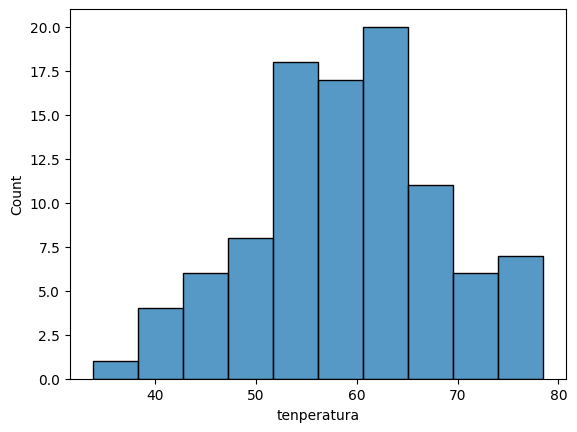

In [ ]:
# Zure kodea hemen:
ax = sns.histplot(df_clean['tenperatura'])

# Balioztapena:
assert ax is not None, "Irudiaren ardatza ax aldagaian gorde behar da!"
print('✅ Zuzena!')


**Ariketa 5.3:** Egin scatter plot bat `sns.scatterplot` erabiliz, x-ardatzean `tenperatura` eta y-ardatzean `bibrazioa` jarriz. Datuak `df_clean` izan behar dira. Gorde emaitza `ax_scatter` aldagaian.


✅ Zuzena!


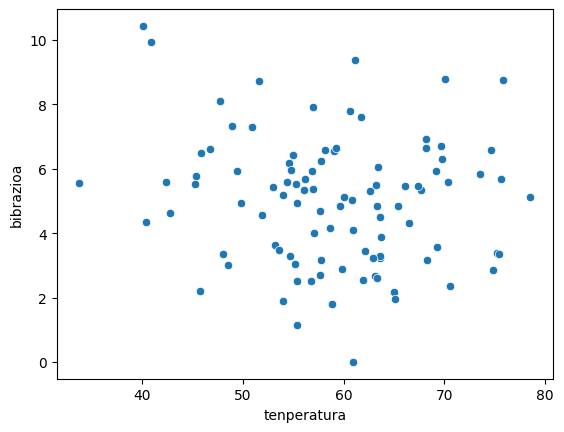

In [ ]:
# Zure kodea hemen:
ax_scatter = sns.scatterplot(data=df_clean, x='tenperatura', y='bibrazioa')

# Balioztapena:
assert ax_scatter is not None, "Gorde plot-a ax_scatter aldagaian!"
print('✅ Zuzena!')


**Ariketa 5.4:** Egin boxplot bat `sns.boxplot` erabiliz. x-ardatzean `makina_id` jarri eta y-ardatzean `tenperatura`. Gorde `ax_box` aldagaian.


✅ Zuzena!


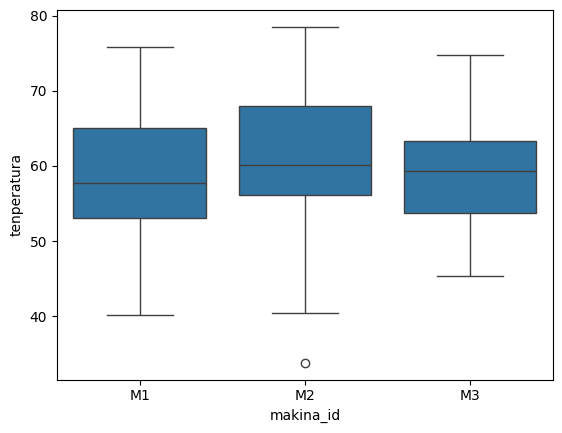

In [ ]:
# Zure kodea hemen:
ax_box = sns.boxplot(data=df_clean, x='makina_id', y='tenperatura')

# Balioztapena:
assert ax_box is not None, "Gorde plot-a ax_box aldagaian!"
print('✅ Zuzena!')


**Ariketa 5.5:** Sortu korrelazio matrize bat `df_clean`-en zutabe numerikoekin, eta egin heatmap bat `sns.heatmap` erabiliz. Gorde heatmap-a `ax_heat` aldagaian.


✅ Zuzena!


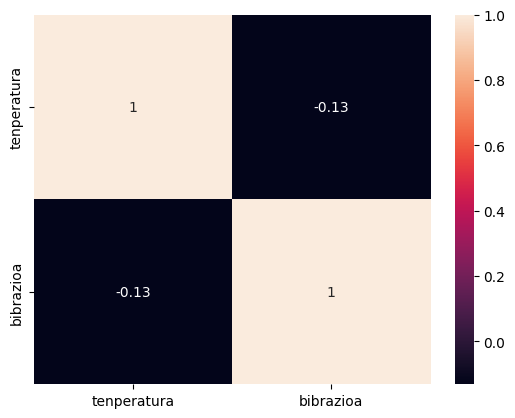

In [ ]:
# Zure kodea hemen:
corr_matrix = df_clean.select_dtypes(include=[np.number]).corr()
ax_heat = sns.heatmap(corr_matrix, annot=True)

# Balioztapena:
assert ax_heat is not None, "Gorde plot-a ax_heat aldagaian!"
print('✅ Zuzena!')


## APUNTEETAKO ARIKETAK



### **Ariketa 3.1**, 27. orrialdea



Egoera: Klase bateko datuak: ikasleak, notak, ordu-kopurua.

Eginkizuna:
1. Barra-grafikoa: ikasleen notak.
2. Sakabanaketa: ordu-kopurua vs nota.
3. 2×2 subplots lau motarekin.
4. PNG + PDF esportatu.

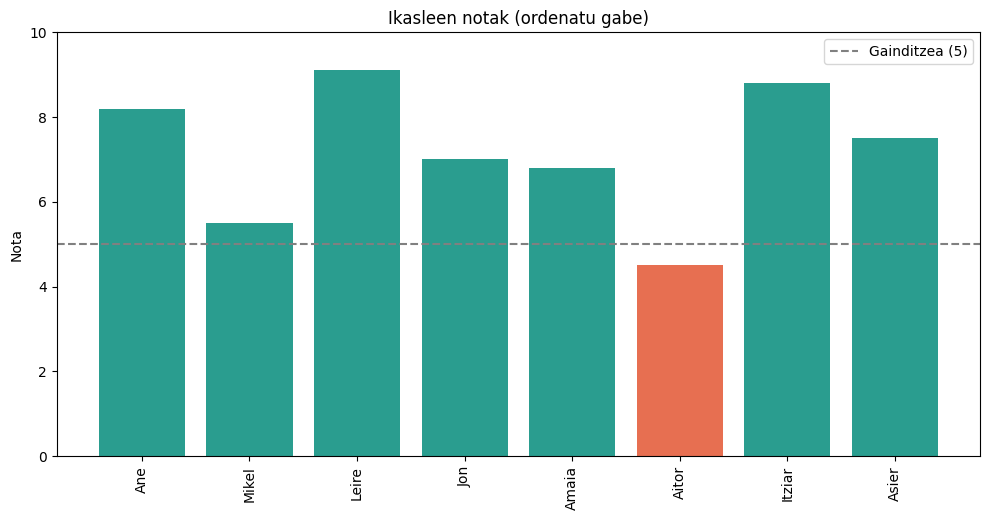

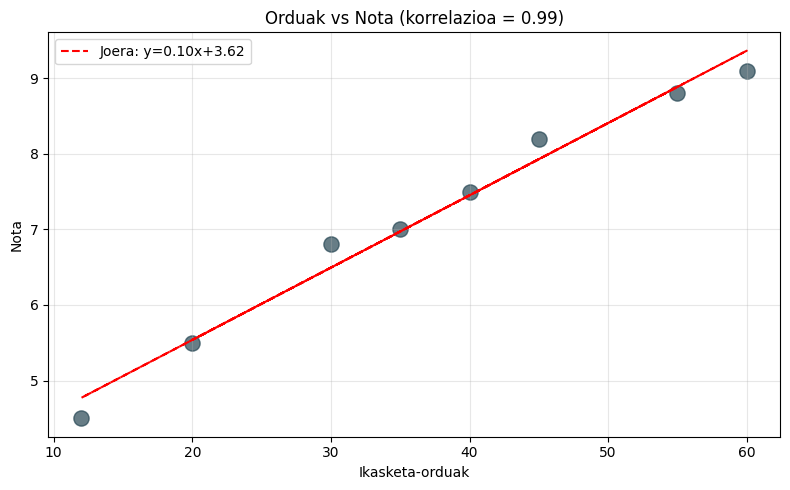

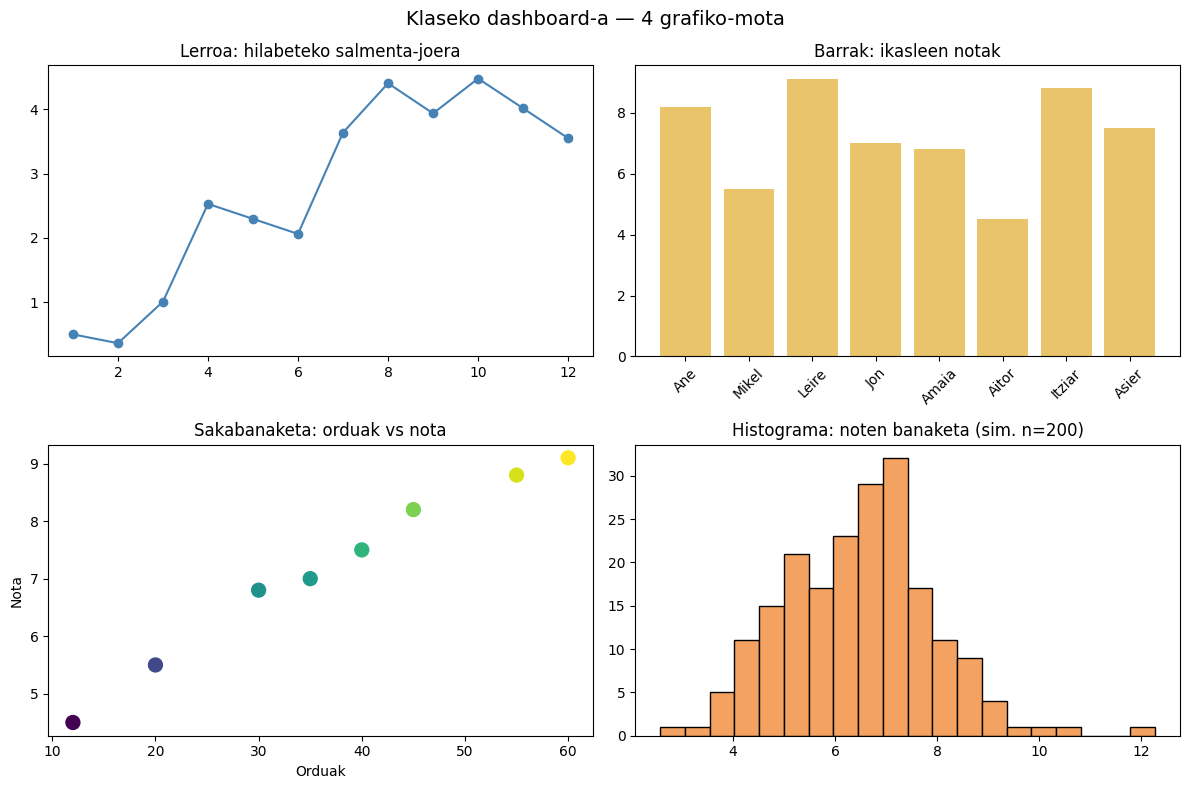

In [2]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
ikasleak = ["Ane", "Mikel", "Leire", "Jon", "Amaia", "Aitor", "Itziar", "Asier"]
notak = np.array([8.2, 5.5, 9.1, 7.0, 6.8, 4.5, 8.8, 7.5])
orduak = np.array([45, 20, 60, 35, 30, 12, 55, 40])

# 1. Barra-grafikoa: ikasleen notak
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    ikasleak,
    notak,
    color=["#2a9d8f" if n >= 5 else "#e76f51" for n in notak],
)
ax.axhline(5, color="gray", linestyle="--", label="Gainditzea (5)")
ax.set_title("Ikasleen notak (ordenatu gabe)")
ax.set_ylabel("Nota")
ax.set_ylim(0, 10)
ax.legend()
plt.tight_layout()
plt.xticks(rotation=90) #bertikalki xizenak
plt.savefig("01_notak_barra.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. Sakabanaketa: orduak vs nota + tendentzia-lerroa
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(orduak, notak, s=120, alpha=0.7, color="#264653")
# Erregresio lineala
m, c = np.polyfit(orduak, notak, 1)
ax.plot(orduak, m*orduak + c, "r--", label=f"Joera: y={m:.2f}x+{c:.2f}")
korr = np.corrcoef(orduak, notak)[0, 1]
ax.set_title(f"Orduak vs Nota (korrelazioa = {korr:.2f})")
ax.set_xlabel("Ikasketa-orduak")
ax.set_ylabel("Nota")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3. 2x2 subplots lau motarekin
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].plot(range(1, 13), np.cumsum(np.random.randn(12)),
               marker="o", color="steelblue")
axs[0, 0].set_title("Lerroa: hilabeteko salmenta-joera")

axs[0, 1].bar(ikasleak, notak, color="#e9c46a")
axs[0, 1].set_title("Barrak: ikasleen notak")
axs[0, 1].tick_params(axis="x", rotation=45)

axs[1, 0].scatter(orduak, notak, c=notak, cmap="viridis", s=100)
axs[1, 0].set_title("Sakabanaketa: orduak vs nota")
axs[1, 0].set_xlabel("Orduak"); axs[1, 0].set_ylabel("Nota")

axs[1, 1].hist(np.random.normal(6.5, 1.5, 200), bins=20, color="#f4a261", edgecolor="black")
axs[1, 1].set_title("Histograma: noten banaketa (sim. n=200)")

plt.suptitle("Klaseko dashboard-a — 4 grafiko-mota", fontsize=14)
plt.tight_layout()

# 4. Esportazioa hiru formatutan
fig.savefig("dashboard.png", dpi=150, bbox_inches="tight")
fig.savefig("dashboard.pdf", bbox_inches="tight")
fig.savefig("dashboard.svg", bbox_inches="tight")
plt.show()

Beste alternatiba lehen grafikorako baina SEABORN erabiliz

DataFrame from student data:


,ikaslea,nota
0,Ane,8.2
1,Mikel,5.5
2,Leire,9.1
3,Jon,7.0
4,Amaia,6.8


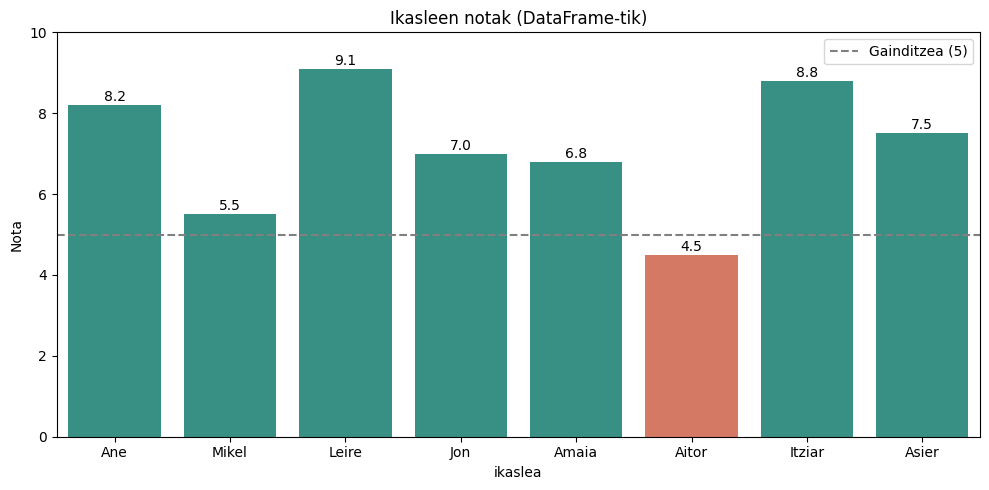

In [ ]:
import pandas as pd

# Datuak csv fitxategitik irakurri izan bagenitu gisara DF batekin hasteko
df_ikasleak = pd.DataFrame({
    'ikaslea': ikasleak,
    'nota': notak
})

print("DataFrame from student data:")
display(df_ikasleak.head())

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x='ikaslea', y='nota', data=df_ikasleak, hue='ikaslea',
            palette=['#2a9d8f' if n >= 5 else '#e76f51' for n in df_ikasleak['nota']])

ax.axhline(5, color='gray', linestyle='--', label='Gainditzea (5)')
ax.set_title('Ikasleen notak (DataFrame-tik)')
ax.set_ylabel('Nota')
ax.set_ylim(0, 10)
ax.legend()

# Balio testuak eransteko barrei
for index, row in df_ikasleak.iterrows():
    ax.text(index, row['nota'] + 0.1, f"{row['nota']:.1f}", ha="center")

plt.tight_layout()
#plt.xticks(rotation=90)
plt.show()

Aukerarik xumeena (MatplotLib hutsa ezarpenik gabe):

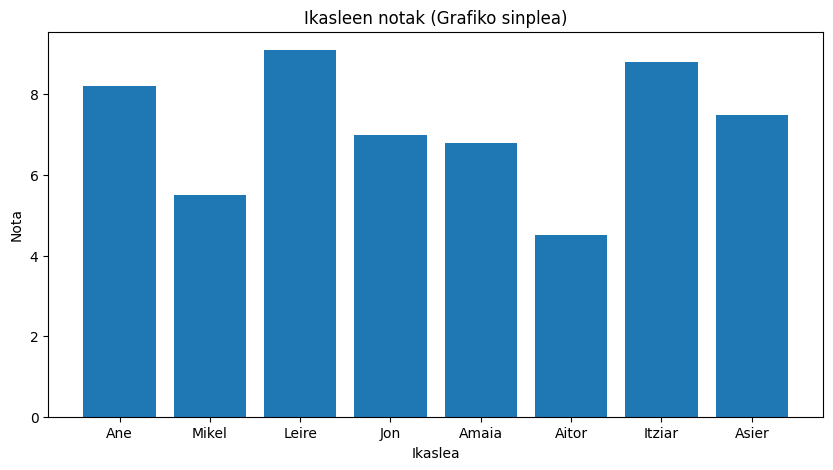

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(ikasleak, notak)
ax.set_title('Ikasleen notak (Grafiko sinplea)')
ax.set_ylabel('Nota')
ax.set_xlabel('Ikaslea')
plt.show()

### **Ariketa 3.2**, 30. orrialdea

Egoera: Klasiko-klasikoa: sns.load_dataset("tips") — jatetxe-propinen datu-multzoa.

Eginkizuna:
1.  tip-aren histograma egunaren arabera.
2.  total_bill-aren boxplot egunaren arabera.
3.  total_bill vs tip sakabanaketa, ordu-tarteaz koloreztatua.
4.  Korrelazio-heatmap.


   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object


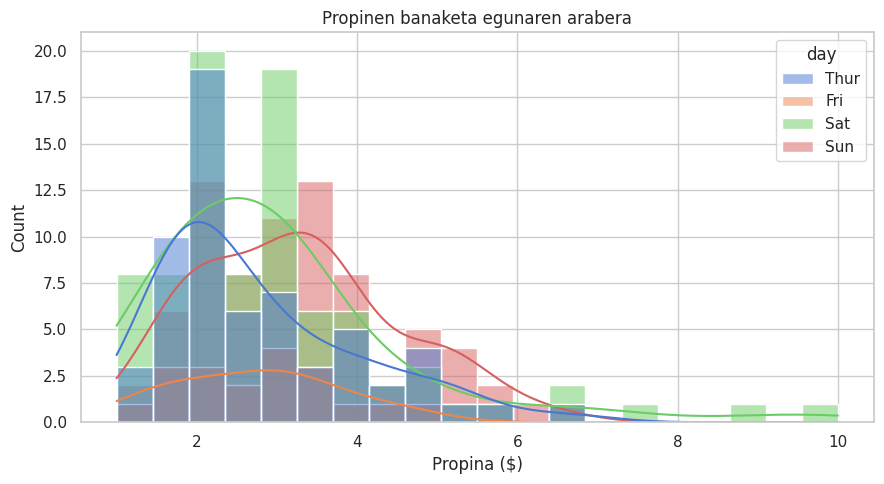

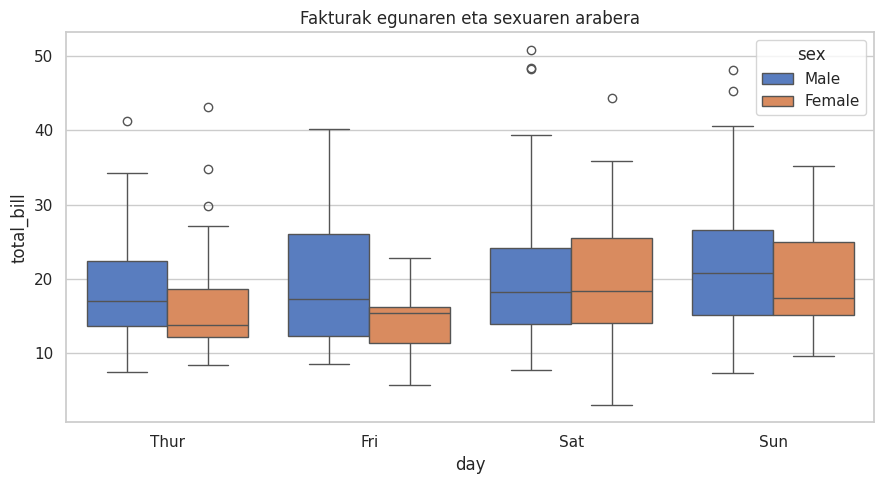

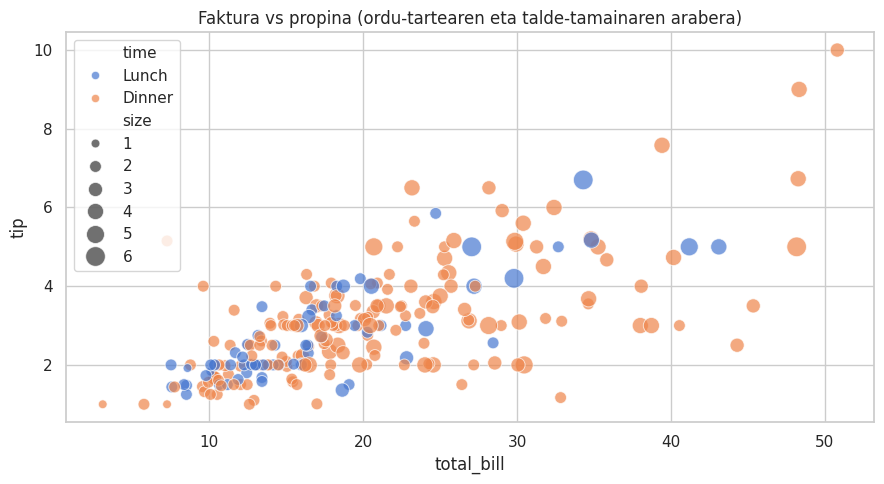


Korrelazio-matrizea:
            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00


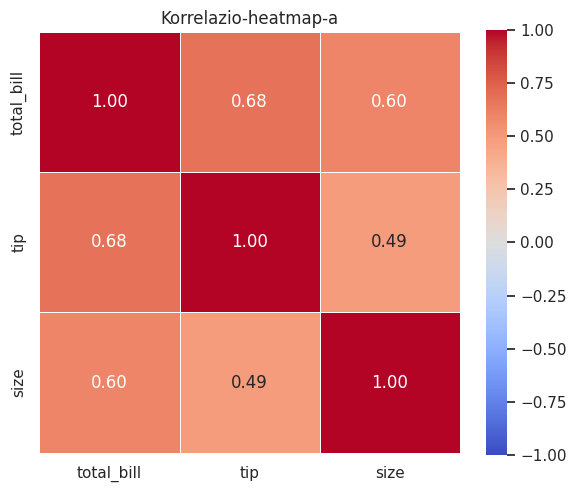

In [ ]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="muted")

df = sns.load_dataset("tips")
print(df.head())
print(df.dtypes)

# 1. Histograma — propinak egunaren arabera
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="tip", hue="day", multiple="layer",
             kde=True, bins=20, alpha=0.5)
plt.title("Propinen banaketa egunaren arabera")
plt.xlabel("Propina ($)")
plt.tight_layout(); plt.show()

# 2. Boxplot — fakturak egunaren arabera
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="day", y="total_bill", hue="sex",
            order=["Thur", "Fri", "Sat", "Sun"])
plt.title("Fakturak egunaren eta sexuaren arabera")
plt.tight_layout()
plt.show()

# 3. Sakabanaketa — total_bill vs tip, ordu-tartearen arabera
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="total_bill", y="tip",
                hue="time", size="size", sizes=(40, 200), alpha=0.7)
plt.title("Faktura vs propina (ordu-tartearen eta talde-tamainaren arabera)")
plt.tight_layout(); plt.show()

# 4. Korrelazio-heatmap zenbakizko zutabeekin
zenbakizko = df.select_dtypes(include="number")
korr = zenbakizko.corr()
print("\nKorrelazio-matrizea:")
print(korr.round(2))

plt.figure(figsize=(6, 5))
sns.heatmap(korr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Korrelazio-heatmap-a")
plt.tight_layout(); plt.show()
